In [28]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Train shape: {x_train.shape}, {y_train.shape}")
print(f"Test shape: {x_test.shape}, {y_test.shape}")

Train shape: (60000, 28, 28), (60000,)
Test shape: (10000, 28, 28), (10000,)


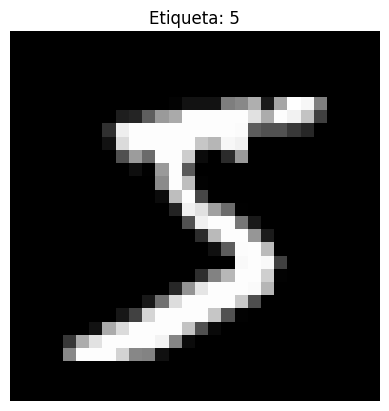

In [5]:
import matplotlib.pyplot as plt

# Mostrar la primera imagen del set de entrenamiento
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis('off')
plt.show()

In [29]:
# Normalizar los valores de las imágenes entre 0 y 1
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# Mostrar el valor de un pixel blanco y uno negro
print(f"Pixel blanco (valor máximo): {x_train_norm[0].max()} (debería ser 1)")
print(f"Pixel negro (valor mínimo): {x_train_norm[0].min()} (debería ser 0)")

Pixel blanco (valor máximo): 1.0 (debería ser 1)
Pixel negro (valor mínimo): 0.0 (debería ser 0)


Epoch 1/25


c:\Cursos\React\modelo\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


468/468 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.6971 - loss: 1.3359 - val_accuracy: 0.9536 - val_loss: 0.5227
Epoch 2/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.6971 - loss: 1.3359 - val_accuracy: 0.9536 - val_loss: 0.5227
Epoch 2/25
  1/468 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8984 - loss: 0.7913

c:\Cursos\React\modelo\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8984 - loss: 0.7913 - val_accuracy: 0.9539 - val_loss: 0.5222
Epoch 3/25
Epoch 3/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8746 - loss: 0.7453 - val_accuracy: 0.9628 - val_loss: 0.4288
Epoch 4/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8746 - loss: 0.7453 - val_accuracy: 0.9628 - val_loss: 0.4288
Epoch 4/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9141 - loss: 0.6282 - val_accuracy: 0.9623 - val_loss: 0.4297
Epoch 5/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9141 - loss: 0.6282 - val_accuracy: 0.9623 - val_loss: 0.4297
Epoch 5/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8969 - loss: 0.6270 - val_accuracy: 0.9570 - val_loss: 0.3921
Epoch 6/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8969 - loss: 0.6270 - val_accuracy: 0.9570 - val_loss: 0.3921
Epoch 6/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8984 - loss: 0.5730 - val_accu

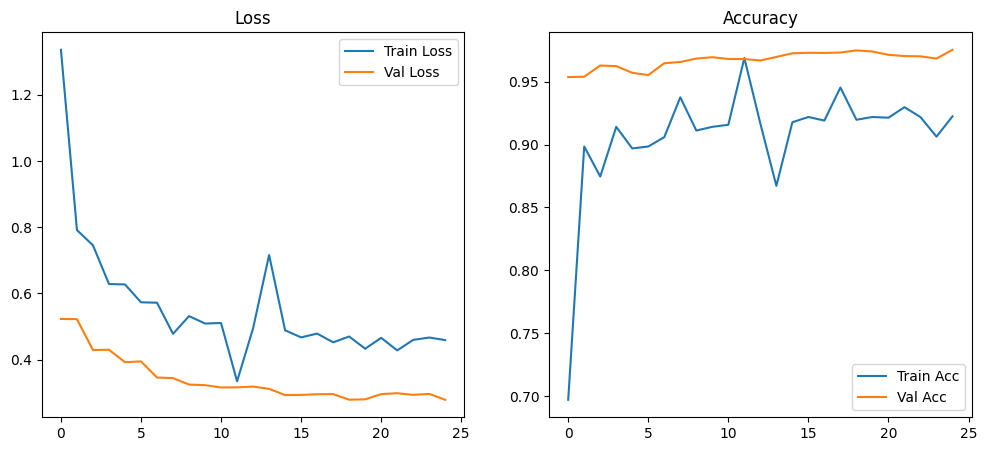

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


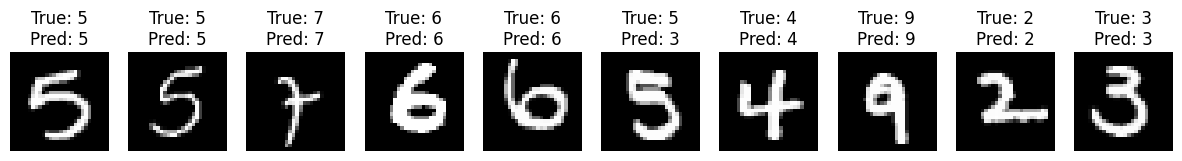

In [33]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.utils import to_categorical
from keras import regularizers
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Preparar los datos
x_train_flat = x_train_norm.reshape(-1, 28, 28, 1)
x_test_flat = x_test_norm.reshape(-1, 28, 28, 1)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Data augmentation

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(x_train_flat)

# Construir el modelo mejorado
model = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con data augmentation y más épocas
epochs = 25
batch_size = 128
history = model.fit(
    datagen.flow(x_train_flat, y_train_cat, batch_size=batch_size),
    steps_per_epoch=len(x_train_flat) // batch_size,
    epochs=epochs,
    validation_data=(x_test_flat, y_test_cat),
    verbose=1
)

# Evaluar el modelo
loss, accuracy = model.evaluate(x_test_flat, y_test_cat, verbose=0)
print(f"Test loss: {loss:.4f}, Test accuracy: {accuracy:.4f}")

# Graficar curvas de entrenamiento
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

# Mostrar predicciones sobre 10 imágenes aleatorias
def show_predictions(model, x, y, n=10):
    idx = np.random.choice(len(x), n, replace=False)
    images = x[idx].reshape(-1, 28, 28)
    true_labels = np.argmax(y[idx], axis=1)
    preds = np.argmax(model.predict(x[idx]), axis=1)
    plt.figure(figsize=(15,3))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"True: {true_labels[i]}\nPred: {preds[i]}")
        plt.axis('off')
    plt.show()

show_predictions(model, x_test_flat, y_test_cat, n=10)

In [8]:
# Exportar el modelo entrenado a un archivo HDF5
model.save('modelo_mnist.h5')
print('Modelo exportado como modelo_mnist.h5')

Modelo exportado como modelo_mnist.h5


In [34]:
# Exportar el modelo en el formato nativo de Keras recomendado
model.save('modelo_mnist.keras')
print('Modelo exportado como modelo_mnist.keras')

Modelo exportado como modelo_mnist.keras


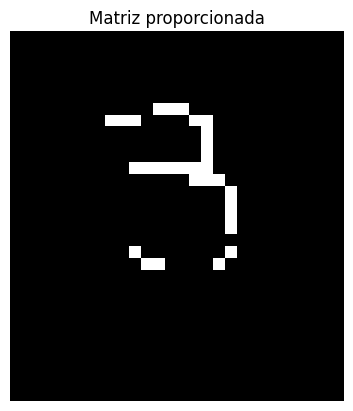

In [12]:
# Dibujar la nueva matriz proporcionada como imagen 28x28
import numpy as np
import matplotlib.pyplot as plt

matriz = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

plt.imshow(matriz, cmap='gray')
plt.title('Matriz proporcionada')
plt.axis('off')
plt.show()

C:\Users\harold.calderon.SOFKA\AppData\Local\Temp\ipykernel_18304\1912214733.py:8: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  matriz_gorda = morphology.dilation(matriz, morphology.square(2))  # Puedes aumentar el tamaño para engrosar más


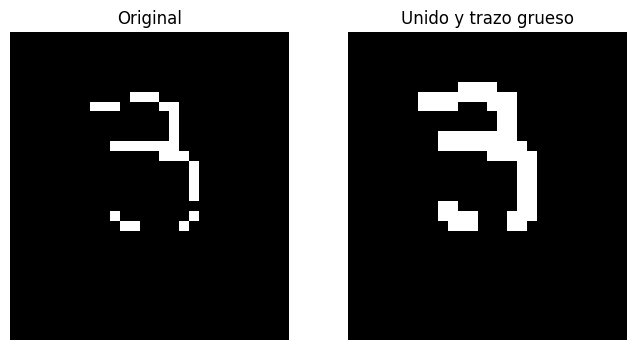

In [36]:
# Unir y engrosar los puntos blancos (1) usando dilatación (scikit-image)
from skimage import morphology
import matplotlib.pyplot as plt
import numpy as np

# La matriz ya está definida como 'matriz' (0=fondo, 1=trazo)
# Aplicar dilatación para unir y engrosar los unos
matriz_gorda = morphology.dilation(matriz, morphology.square(2))  # Puedes aumentar el tamaño para engrosar más

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(matriz, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(matriz_gorda, cmap='gray')
plt.title('Unido y trazo grueso')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Predicción del modelo: 3
Predicción del modelo: 3


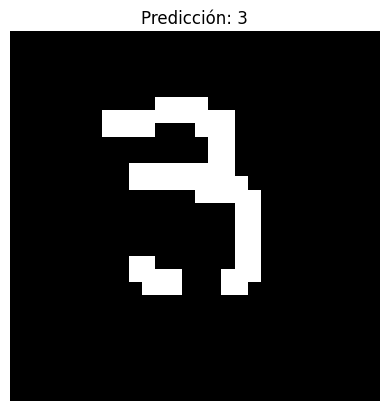

In [35]:
# Evaluar la matriz engrosada en el modelo y mostrar la predicción
if 'matriz_gorda' in locals():
    # Asegurarse de que la matriz tenga forma (28,28)
    matriz_ajustada = np.zeros((28,28), dtype='float32')
    m, n = matriz_gorda.shape
    matriz_ajustada[:m, :n] = matriz_gorda[:28, :28]
    # Normalizar y dar forma adecuada
    matriz_input = matriz_ajustada.reshape(1, 28, 28, 1).astype('float32')
    # Predecir
    pred = model.predict(matriz_input)
    print(f"Predicción del modelo: {np.argmax(pred)}")
    plt.imshow(matriz_ajustada, cmap='gray')
    plt.title(f"Predicción: {np.argmax(pred)}")
    plt.axis('off')
    plt.show()
else:
    print('Primero ejecuta la celda de dilatación para obtener matriz_gorda.')